In [5]:
import xarray as xr
import glob, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import urllib.request
import matplotlib.gridspec as gridspec
from scipy.stats import linregress
import cartopy.crs as ccrs
import matplotlib.path as mpath
import matplotlib as mpl
import matplotlib.patches as mpatches
from cartopy.util import add_cyclic_point
from scipy.signal import detrend
import EDJ_PNAS_functions as fedj

In [3]:
base_dir = '/climca/people/jmindlin/esmvaltool_output/full_storyline_analysis_complete_20240902_145448/preproc/multiple_regression_indices/ua850'

# Use glob to find all NetCDF files
files = glob.glob(os.path.join(base_dir, "*.nc"))

# Dictionary to store datasets per model
model_datasets = {}

def standardize_time(ds):
    """Convert dataset time coordinates to a standard calendar."""
    if "time" in ds.coords:
        ds["time"] = xr.decode_cf(ds).time  # Decode time while handling different calendars
    return ds

# Process files
for file in files:
    # Extract model and ensemble member from filename
    filename = os.path.basename(file)
    parts = filename.split("_")
    model = parts[1]  # Extract model name (e.g., ACCESS-CM2)
    ensemble = parts[4]  # Extract ensemble member (e.g., r1i1p1f1)
    
    # Open the dataset and standardize time
    ds = xr.open_dataset(file)
    ds = standardize_time(ds)
    
    # Store in dictionary under the model
    if model not in model_datasets:
        model_datasets[model] = []
    model_datasets[model].append(ds)

# List to store mean datasets per model
model_means = []
all_ensemble_members = {}

# Process each model
for model, ds_list in model_datasets.items():
    # Concatenate over a new ensemble dimension
    combined = xr.concat(ds_list, dim="ensemble")
    all_ensemble_members[model] = combined
    
    # Take the mean over the ensemble dimension
    mean_ds = combined.mean(dim="ensemble")
    
    # Add a new coordinate for model
    mean_ds = mean_ds.expand_dims({"model": [model]})
    
    # Store the processed dataset
    model_means.append(mean_ds)


model_means_same_time = []
# Concatenate all models along the model dimension
for model in model_means:
    model['time'] = model_means[0].time
    for i,member in enumerate(all_ensemble_members[str(model.model[0].values)].ensemble):
        all_ensemble_members[str(model.model[0].values)].isel(ensemble=i)['time'] = model_means[0].time
    model_means_same_time.append(model)

final_u850 = xr.concat(model_means_same_time, dim="model")


In [6]:
lats_ZM, strs_ZM = [], []
lats_Pa, strs_Pa = [], []
lats_At, strs_At = [], []

for m in all_ensemble_members.keys():
    for i, member in enumerate(all_ensemble_members[m].ensemble):
        for region, lon_bounds, lat_list, str_list in [
            ('ZM', (-180, 180), lats_ZM, strs_ZM),
            ('Pa', (-200, -80), lats_Pa, strs_Pa),
            ('At', (-40, 140), lats_At, strs_At)
        ]:
            lat, strength = fedj.jet_lat_strength_model(
                all_ensemble_members[m].isel(ensemble=i).ua.sel(time=slice('1950', '2023')),
                *lon_bounds
            )

            # Compute anomalies
            lat_anom = lat - np.mean(lat[:30])
            str_anom = strength - np.mean(strength[:30])

            # Time index for slope computation
            time_idx = np.arange(len(lat_anom))

            # Save slope instead of time series
            lat_list.append(np.polyfit(time_idx, lat_anom, 1)[0])
            str_list.append(np.polyfit(time_idx, str_anom, 1)[0])

# Convert to arrays of slopes
lats_ZM = np.array(lats_ZM)
strs_ZM = np.array(strs_ZM)
lats_Pa = np.array(lats_Pa)
strs_Pa = np.array(strs_Pa)
lats_At = np.array(lats_At)
strs_At = np.array(strs_At)

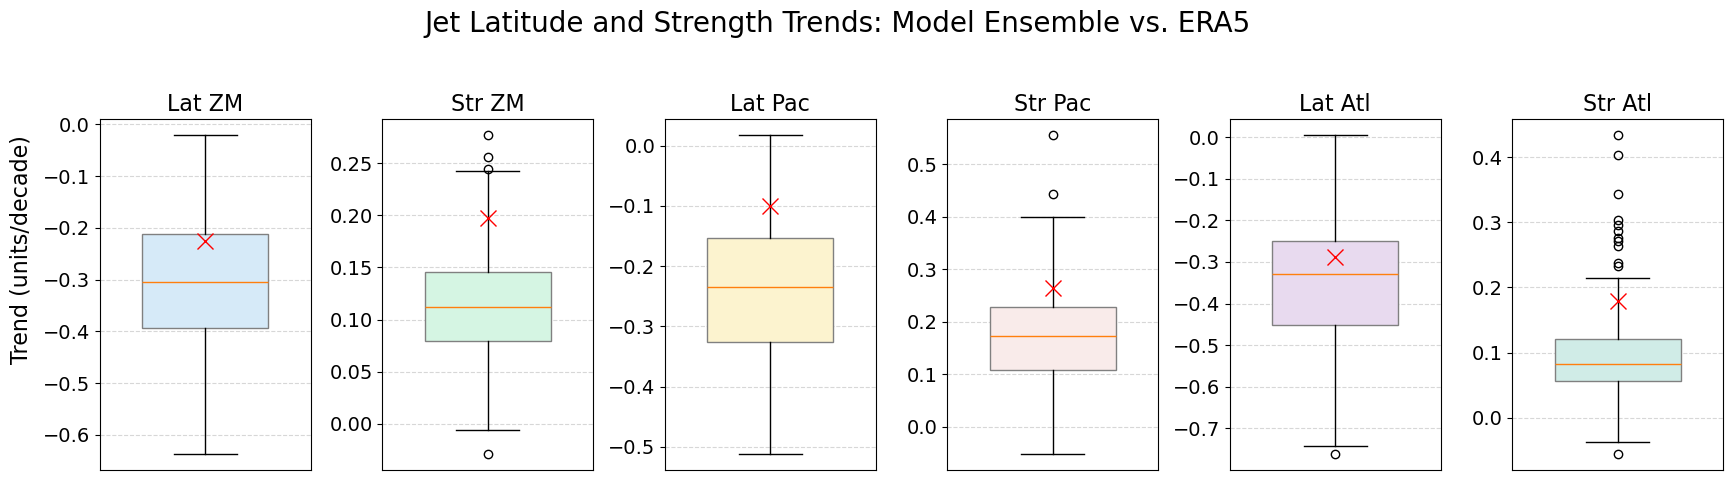

In [7]:

# === Compute ERA5 trends ===
def compute_trend(series):
    return np.polyfit(np.arange(len(series)), series - np.mean(series[:30]), 1)[0]

lat_str_era5 = pd.read_csv("/climca/people/jmindlin/work_folders/EDJ_causal_network/FinalCodes/Notebooks/PublishedFiles/jet_lat_strength_era5.csv")

era5_trends = [
    compute_trend(lat_str_era5['lat_global']),
    compute_trend(lat_str_era5['str_global']),
    compute_trend(lat_str_era5['lat_Pacific']),
    compute_trend(lat_str_era5['str_Pacific']),
    compute_trend(lat_str_era5['lat_Atlantic']),
    compute_trend(lat_str_era5['str_Atlantic']),
]

# === Combine model trends into list of lists ===
model_trends = [lats_ZM, strs_ZM, lats_Pa, strs_Pa, lats_At, strs_At]

# === Plotting ===
labels = ['Lat ZM', 'Str ZM', 'Lat Pac', 'Str Pac', 'Lat Atl', 'Str Atl']
colors = ['#d6eaf8', '#d5f5e3', '#fcf3cf', '#f9ebea', '#e8daef', '#d0ece7']

fig, axes = plt.subplots(1, 6, figsize=(18, 5), dpi=300, sharey=False)

for i, ax in enumerate(axes):
    box = ax.boxplot(model_trends[i]*10, patch_artist=True, widths=0.6)
    for patch in box['boxes']:
        patch.set_facecolor(colors[i])
        patch.set_edgecolor('gray')
    
    # Add ERA5 trend as red cross
    ax.plot(1, era5_trends[i]*10, marker='x', color='red', markersize=12, label='ERA5')

    ax.set_title(labels[i], fontsize=16)
    ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# Shared Y-axis label
fig.text(0.04, 0.5, 'Trend (units/decade)', va='center', rotation='vertical', fontsize=16)

plt.tight_layout(rect=[0.05, 0.03, 1, 0.93])
plt.show()


In [8]:

lats_ZM_model, strs_ZM_model = [], []
lats_Pa_model, strs_Pa_model = [], []
lats_At_model, strs_At_model = [], []

for m in all_ensemble_members.keys():
    for region, lon_bounds, lat_list, str_list in [
        ('ZM', (-180, 180), lats_ZM_model, strs_ZM_model),
        ('Pa', (-200, -80), lats_Pa_model, strs_Pa_model),
        ('At', (-40, 140), lats_At_model, strs_At_model)
    ]:
        lat, strength = fedj.jet_lat_strength_model(
            all_ensemble_members[m].mean(dim ='ensemble').ua.sel(time=slice('1950', '2023')),
            *lon_bounds
        )

        # Compute anomalies
        lat_anom = lat - np.mean(lat[:30])
        str_anom = strength - np.mean(strength[:30])

        # Time index for slope computation
        time_idx = np.arange(len(lat_anom))

        # Save slope instead of time series
        lat_list.append(np.polyfit(time_idx, lat_anom, 1)[0])
        str_list.append(np.polyfit(time_idx, str_anom, 1)[0])

# Convert to arrays of slopes
lats_ZM_model = np.array(lats_ZM_model)
strs_ZM_model = np.array(strs_ZM_model)
lats_Pa_model = np.array(lats_Pa_model)
strs_Pa_model = np.array(strs_Pa_model)
lats_At_model = np.array(lats_At_model)
strs_At_model = np.array(strs_At_model)


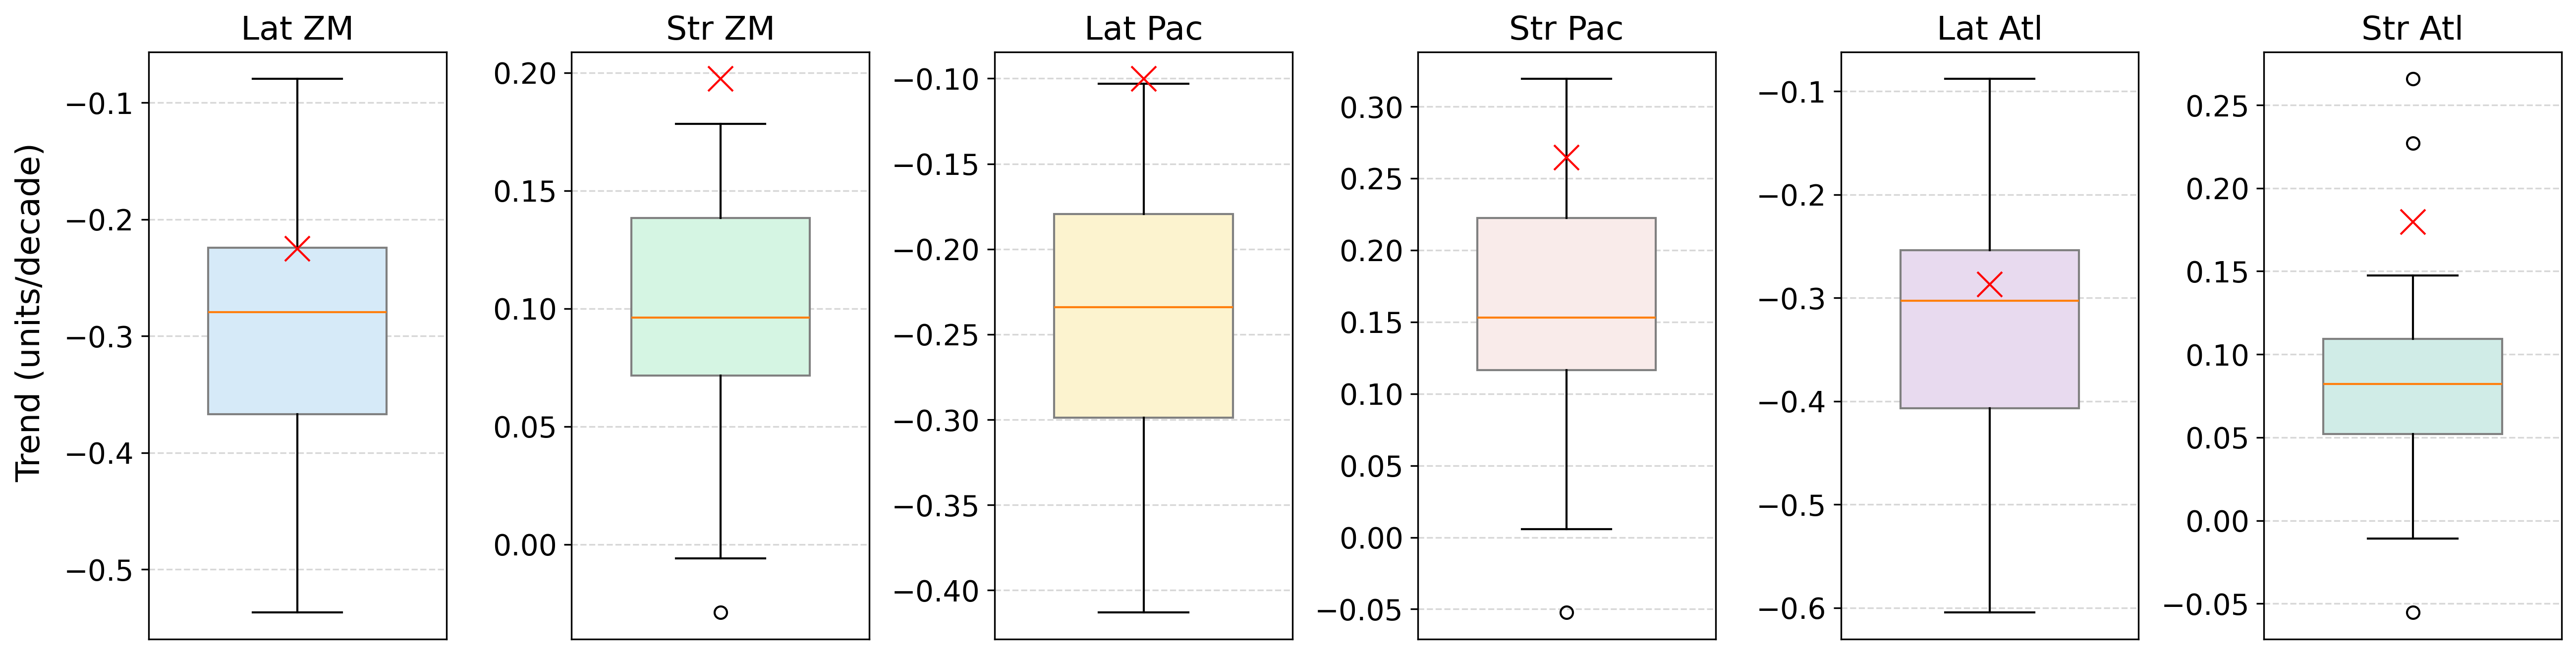

In [10]:

# === Combine model trends into list of lists ===
model_trends = [lats_ZM_model, strs_ZM_model, lats_Pa_model, strs_Pa_model, lats_At_model, strs_At_model]

# === Plotting ===
labels = ['Lat ZM', 'Str ZM', 'Lat Pac', 'Str Pac', 'Lat Atl', 'Str Atl']
colors = ['#d6eaf8', '#d5f5e3', '#fcf3cf', '#f9ebea', '#e8daef', '#d0ece7']

fig, axes = plt.subplots(1, 6, figsize=(18, 5), dpi=300, sharey=False)

for i, ax in enumerate(axes):
    box = ax.boxplot(model_trends[i]*10, patch_artist=True, widths=0.6)
    for patch in box['boxes']:
        patch.set_facecolor(colors[i])
        patch.set_edgecolor('gray')
    
    # Add ERA5 trend as red cross
    ax.plot(1, era5_trends[i]*10, marker='x', color='red', markersize=12, label='ERA5')

    ax.set_title(labels[i], fontsize=16)
    ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# Shared Y-axis label
fig.text(0.04, 0.5, 'Trend (units/decade)', va='center', rotation='vertical', fontsize=16)


plt.tight_layout(rect=[0.05, 0.03, 1, 0.93])
plt.show()
